# Gutenberg-Richter Recurrence Model Fitting

One of the fundamental components of [Probabilistic Seismic Hazard Analysis (PSHA) ](https://gemsciencetools.github.io/quakeT/contents/glossary.html#term-Probabilistic-Seismic-Hazard-Analysis-PSHA) is characterizing the seismicity of a source region by defining its [Magnitude-Frequency Distribution (MFD)](https://gemsciencetools.github.io/quakeT/contents/glossary.html#term-MagnitudeFrequency-Distribution-MFD). The MFD quantifies the expected annual rate of earthquakes exceeding a specific magnitude threshold. 

The baseline mathematical framework for this analysis is the classic **Gutenberg-Richter (G-R) recurrence law** [[10]](references.html#ref-gr-1944), expressed as:

$$\log_{10} N(M) = a - bM$$

Where:
- **N(M)** is the cumulative annual rate of earthquakes with magnitudes greater than or equal to $M$.
- **a-value** represents the overall level of seismicity (productivity) of the zone.
- **b-value** indicates the relative ratio of small to large earthquakes.

This notebook provides a workflow for analyzing an [earthquake catalogue](https://gemsciencetools.github.io/quakeT/contents/glossary.html#term-Earthquake-catalogue) and fitting recurrence parameters using the OpenQuake Hazard Modeller's Toolkit [[1]](references.html#ref-weatherill-2014). Specifically, we present two different algorithms to derive the Gutenberg-Richter parameters: Aki Maximum Likelihood and B-Value Maximum Likelihood (Both is available in [openquake.hmtk.seismicity.occurrence](https://github.com/gem/oq-engine/tree/master/openquake/hmtk/seismicity/occurrence)).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from openquake.hmtk.seismicity.catalogue import Catalogue
from openquake.hmtk.seismicity.occurrence.aki_maximum_likelihood import AkiMaxLikelihood
from openquake.hmtk.seismicity.occurrence.b_maximum_likelihood import BMaxLikelihood

## Aki Maximum Likelihood (`AkiMaxLikelihood`)
Developed by Aki (1965) [[11]](references.html#ref-aki-1965) and implemented here with the discrete bin-width correction by Bender (1983) [[12]](references.html#ref-bender-1983), this method estimates the $b$-value using a Maximum Likelihood Estimation (MLE) approach. 

While the original Aki formulation assumes a continuous magnitude distribution, earthquake catalogues group magnitudes into discrete bins (e.g., $\Delta M = 0.1$). To prevent statistical bias arising from this discretization, the code integrates Bender's correction factor and formulates the calculation as:

$$b = \frac{\log_{10}e}{\bar{M} - M_{min} + \frac{\Delta M}{2}}$$

Where:
- $\mathbf{\bar{M}}$ (`m_ave`): The mean magnitude of the events that are equal to or greater than the completeness magnitude ($M \geq M_c$).
- $\mathbf{M_{min}}$ (`m_min`): The minimum discrete magnitude bin placeholder above or equal to $M_c$ within the sample.
- $\mathbf{\Delta M}$ (`dmag`): The magnitude bin width interval (typically $0.1$).

The standard deviation ($\sigma_b$) of the estimated $b$-value is computed using the sample variance weighted by the number of observations per bin, following Bender's uncertainty estimator:

$$\sigma_b = \ln(10) \cdot b^2 \cdot \sqrt{\frac{\sum (M_i - \bar{M})^2}{N(N - 1)}}$$

The required input for `AkiMaxLikelihood` algorithm is briefly described below. For more detailed information, please see [Data Format section](https://gemsciencetools.github.io/quakeT/contents/data_formats.html). 

- **catalogue (str):** Path to the HMTK-formatted CSV catalogue.
- **Mc**: Completeness magnitude for the catalogue.

In [2]:
df = pd.read_csv("../data/hmtk_sample_catalogue.csv")
Mc = 3.5

catalogue = Catalogue()
catalogue.data = {'magnitude': df['magnitude'].values, 'year': df['year'].values.astype(int)}
catalogue.end_year = int(df['year'].max()) 
end_year = int(catalogue.end_year)
start_year = int(catalogue.data['year'].min())
time_span = end_year - start_year + 1

print(f"Start year={start_year}, End year={end_year}, Time Span={time_span} years")

Start year=1, End year=10000, Time Span=10000 years


Below, you see how to obtain $b$-value, its sigma, and $a$-value. 

In [3]:
# b_val and sigma_b calculation
b_val, sigma_b = AkiMaxLikelihood().calculate(catalogue, completeness=Mc)

# a_val calculation
df_complete = df[df["magnitude"] >= Mc]
neq_complete = len(df_complete)

# Annualized earthquake rate (N_cumulative / T)
annual_rate = neq_complete / time_span
a_val = np.log10(annual_rate) + b_val * Mc

print(f"Results: a={a_val:.3f}, b={b_val:.3f} ±{sigma_b:.3f}")

Results: a=3.881, b=0.888 ±0.004


You can plot the FMD using obtained GR parameters, and catalogue.

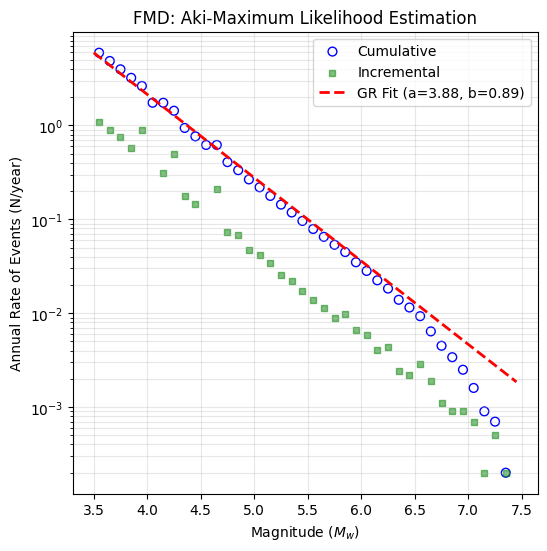

In [4]:
# Plot FMD
bins = np.arange(df["magnitude"].min(), df["magnitude"].max() + 0.1, 0.1)
hist, edges = np.histogram(df["magnitude"], bins=bins)
cum_evars = np.cumsum(hist[::-1])[::-1]
m_model = np.linspace(Mc, df["magnitude"].max(), 100)
v_model = 10 ** (a_val - b_val * m_model)

# Plot
plt.figure(figsize=(6, 6))
plt.scatter(edges[:-1], cum_evars / time_span, s=40, facecolors='none', edgecolors='b', label="Cumulative")
plt.scatter(edges[:-1], hist / time_span, s=20, color="g", marker="s", alpha=0.5, label="Incremental")
plt.plot(m_model, v_model, "r--", linewidth=2, label=f"GR Fit (a={a_val:.2f}, b={b_val:.2f})")
plt.yscale("log")
plt.xlabel("Magnitude ($M_w$)")
plt.ylabel("Annual Rate of Events (N/year)")
plt.title("FMD: Aki-Maximum Likelihood Estimation")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()

## GR parameters with Time-Varying Completeness (`BMaxLikelihood`)

`BMaxLikelihood` algorithm enables an advanced extension based on Utsu (1965) [[13]](references.html#ref-utsu-1965), Weichert (1980) [[14]](references.html#ref-weichert-1980), and Bender (1983) [[12]](references.html#ref-bender-1983) that accounts for both magnitude binning/discretization effects and time-varying [magnitude completeness (Mc)](https://gemsciencetools.github.io/quakeT/contents/glossary.html#term-Magnitude-completeness-Mc). 

[Historical catalogues](https://gemsciencetools.github.io/quakeT/contents/glossary.html#term-Historical-catalogue) are inherently non-homogeneous because seismic networks improve over time; smaller earthquakes are fully captured in recent years, whereas only larger events were recorded in the past. Treating such a partitioned catalogue with a completeness magnitude leads to systematic bias in Gutenberg-Richter parameters.

The `BMaxLikelihood` operates by partitioning the catalogue into distinct temporal windows based on a completeness table (defined by cut-off years $T_i$ and corresponding magnitudes $M_{c,i}$). 

For each chronological interval, the `BMaxLikelihood` isolates compliant events and invokes an underlying Aki MLE sub-routine with Bender’s bin-width ($\Delta M$) correction:

$$b_i = \frac{\log_{10}e}{\bar{M}_i - M_{min,i} + \frac{\Delta M}{2}}$$

Once local $b$-values ($b_i$) and their uncertainties ($\sigma_{b,i}$) are stacked for all valid intervals, a single unified $b_{final}$ is derived using a statistical ensemble approach defined in the configuration (`Weighted` or `Harmonic` mean):

$$b_{final} = \sum_{i=1}^{k} \left( b_i \cdot \frac{N_i}{N_{total}} \right)$$

Where $N_i$ is the number of events in the $i$-th temporal completeness block.

Unlike the `AkiMaxLikelihood`, `BMaxLikelihood` jointly solves for the annualized productivity parameter ($a$-value) using the maximum likelihood solution for multi-period data formulated by Weichert (1980) [[14]](references.html#ref-weichert-1980) and McGuire (2004) [[15]](references.html#ref-mcguire-2004).

$$\lambda(M_{min}) = \frac{\sum_{i=1}^{k} N_i}{\sum_{i=1}^{k} \left( T_i \cdot e^{-\beta M_j} \right)}$$

Where $T_i$ represents the seismic observation duration (years) for each interval, and $\beta = b_{final} \cdot \ln(10)$. The calculated scalar is then mapped back to the baseline minimum magnitude ($M_{min}$) to compute the annualized $a$-value:

$$a = \log_{10}(\lambda(M_{min})) + b_{final} \cdot M_{min}$$

The `BMaxLikelihood` requires specific data structures and configuration parameters to handle time-varying completeness.

- **catalogue**: An instance of the HMTK Catalogue object containing the earthquake database (specifically requires `magnitude` and `year` attributes).
- **completeness** (`numpy.ndarray`): A 2D completeness matrix/table structured as `[[year_1, Mc_1], [year_2, Mc_2], ...]`. It defines the chronological cut-off thresholds where specific magnitude ranges become statistically complete.
- **config** (`dict`): A configuration dictionary containing the execution hyper-parameters:
  * **Average Type** (*str*): Method used to ensemble the multi-period recurrence trends. Options are `"Weighted"` (proportional to event-counts per window, recommended) or `"Harmonic"` mean.
  * **magnitude_interval** (*float*): The magnitude bin width or rounding increment used in the catalog (typically `0.1`), critical for Bender's discretization correction.
  * **completeness** (*bool*): Set to `True` to activate multi-period analysis.
  * **reference_magnitude** (*float*): 
    * If set to `0.0` or `None`, the module executes standard Gutenberg-Richter reporting and returns the annualized $a$-value, $b$-value, and their respective uncertainties.
    * If a specific engineering design magnitude is provided (e.g., $M_w = 5.0$), the algorithm bypasses standard parameter reporting and outputs the calculated **annual exceedance rate** ($\lambda$) and its variance for that exact threshold.

In [5]:
bin_w = 0.1
Mc = 3.5
start_year = int(df["year"].min())
end_year = int(catalogue.end_year)
total_years = end_year - start_year + 1
completeness = np.array([[start_year, Mc]])

# Config
config = {
    "Average Type": "Weighted", 
    "reference_magnitude": 0.0, 
    "magnitude_interval": bin_w,
    "completeness": True
}

In [6]:
# b_val, sigma_b, a_val, and sigma_a calculation
b_val, sigma_b, a_val, sigma_a = BMaxLikelihood().calculate(catalogue, config, completeness)
print(f"Results: a={a_val:.3f} ±{sigma_a:.3f}, b={b_val:.3f} ±{sigma_b:.3f}")

--- ctime 1.0  m_c 3.5
Results: a=3.881 ±0.013, b=0.888 ±0.004


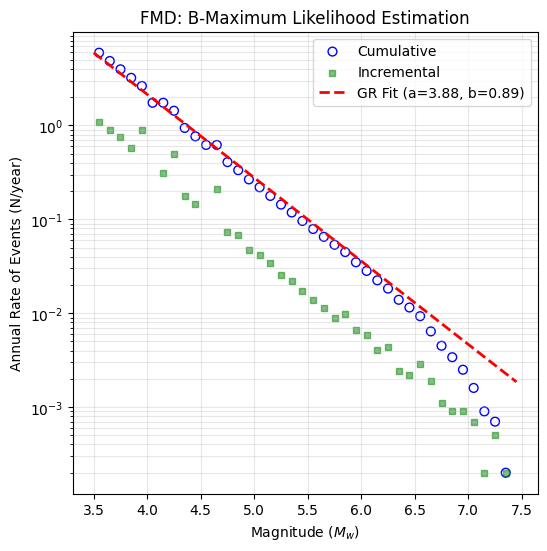

In [7]:
# Plot FMD
m_bins = np.arange(df["magnitude"].min(), df["magnitude"].max() + bin_w, bin_w)
hist, edges = np.histogram(df["magnitude"], bins=m_bins)
cum_events = np.cumsum(hist[::-1])[::-1]
m_model = np.linspace(Mc, df["magnitude"].max(), 100)
gr_model_total = (10 ** (a_val - b_val * m_model))

# Plot
plt.figure(figsize=(6, 6))
plt.scatter(edges[:-1], cum_events / total_years, s=40, facecolors='none', edgecolors='b', label="Cumulative")
plt.scatter(edges[:-1], hist / total_years, s=20, color="g", marker="s", alpha=0.5, label="Incremental")
plt.plot(m_model, gr_model_total, "r--", linewidth=2, label=f"GR Fit (a={a_val:.2f}, b={b_val:.2f})")
plt.yscale("log")
plt.xlabel("Magnitude ($M_w$)")
plt.ylabel(f"Annual Rate of Events (N/year)")
plt.title("FMD: B-Maximum Likelihood Estimation")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()